# Error Analysis

In [8]:
# Load test set
import pandas as pd

Data_PATH = "../data/"

X_test = pd.read_pickle(Data_PATH + "X_test.pkl")
y_test = pd.read_pickle(Data_PATH + "y_test.pkl")

In [11]:
# Load saved artifact
import joblib

Model_PATH = "../models/bot_detection_pipeline_1.joblib"

artifact = joblib.load(Model_PATH)

loaded_pipeline = artifact["pipeline"]
chosen_threshold = artifact["threshold"]

print("Model loaded.")

Model loaded.


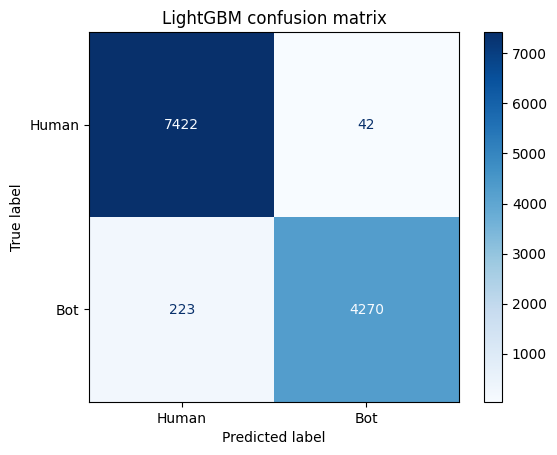

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

lightgbm_probability = (loaded_pipeline.predict_proba(X_test)[:, 1])

lightgbm_pred = (lightgbm_probability >= chosen_threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lightgbm_pred,
    display_labels=["Human", "Bot"],
    cmap="Blues"
)

plt.title("LightGBM confusion matrix")
plt.show()

In [15]:
error_df = X_test.copy()

error_df["y_true"] = np.asarray(y_test)
error_df["probability"] = loaded_pipeline.predict_proba(X_test)[:, 1]
error_df["prediction"] = (error_df["probability"] >= chosen_threshold).astype(int)

error_df["error_type"] = np.select(
    [
        (error_df["y_true"] == 0) & (error_df["prediction"] == 1),
        (error_df["y_true"] == 1) & (error_df["prediction"] == 0),
    ],
    ["false_positive", "false_negative"],
    default="correct",
)

In [16]:
# Inspect the most confident errors

false_positives = (error_df[error_df["error_type"] == "false_positive"].sort_values("probability", ascending=False))

false_negatives = (error_df[error_df["error_type"] == "false_negative"].sort_values("probability", ascending=True))

In [17]:
# Compare error rates by segment
segment_summary = error_df.groupby("visitor_recognition_type").agg(
    observations=("y_true", "size"),
    actual_bots=("y_true", "sum"),
    predicted_bots=("prediction", "sum"),
    errors=("error_type", lambda x: (x != "correct").sum()),
)

segment_summary["error_rate"] = (segment_summary["errors"] / segment_summary["observations"]).mul(100)

segment_summary.sort_values("error_rate", ascending=False)

,observations,actual_bots,predicted_bots,errors,error_rate
visitor_recognition_type,,,,,
ANONYMOUS,8868,4492,4312,264,2.976996
RECOGNIZED,2460,1,0,1,0.040650
LOGGEDIN,629,0,0,0,0.000000


In [18]:
segment_summary = error_df.groupby("country_by_ip_address").agg(
    observations=("y_true", "size"),
    actual_bots=("y_true", "sum"),
    predicted_bots=("prediction", "sum"),
    errors=("error_type", lambda x: (x != "correct").sum()),
)

segment_summary["error_rate"] = (segment_summary["errors"] / segment_summary["observations"]).mul(100)

segment_summary.sort_values("error_rate", ascending=False)

,observations,actual_bots,predicted_bots,errors,error_rate
country_by_ip_address,,,,,
IE,5,4,0,4,80.000000
FR,98,43,0,43,43.877551
RU,19,6,2,4,21.052632
NO,5,1,0,1,20.000000
US,4584,4291,4271,104,2.268761
NL,4976,107,0,107,2.150322
BE,1505,2,0,2,0.132890
BD,3,0,0,0,0.000000
BG,1,0,0,0,0.000000


In [19]:
segment_summary = error_df.groupby("region_by_ip_address").agg(
    observations=("y_true", "size"),
    actual_bots=("y_true", "sum"),
    predicted_bots=("prediction", "sum"),
    errors=("error_type", lambda x: (x != "correct").sum()),
)

segment_summary["error_rate"] = (segment_summary["errors"] / segment_summary["observations"]).mul(100)

segment_summary.sort_values("error_rate", ascending=False)

,observations,actual_bots,predicted_bots,errors,error_rate
region_by_ip_address,,,,,
VLA,4,4,0,4,100.000000
15,1,1,0,1,100.000000
L,1,1,0,1,100.000000
MD,2,2,0,2,100.000000
TX,11,10,0,10,90.909091
...,...,...,...,...,...
WHT,18,0,0,0,0.000000
WKO,1,0,0,0,0.000000
WLG,7,0,0,0,0.000000


Above tables show visitor_recognition_type, country_by_ip_address, and region_by_ip_address are all shortcut candidates, not proven shortcuts.
So an ablation experiment is required:

1. Train with all features.
2. Remove country and region.
3. Remove visitor type.
4. Compare performance and cost using a chronological validation set.
5. Compare segment performance and stability across time.

Also inspect feature importance or SHAP values, but remember: importance shows model reliance, while ablation and future-period evaluation better test whether that reliance generalizes. Most importantly, confirm the eight-label mapping because it may be the source of all these near-perfect relationships.

# Ablation Experiment